In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('mushrooms.csv')
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

<ipython-input-21-7a006c733ffb>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='coolwarm')


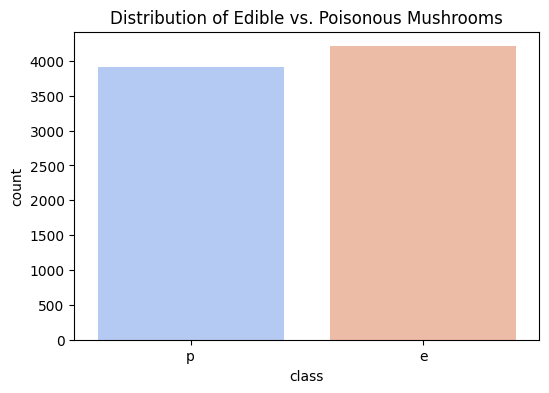

<ipython-input-21-7a006c733ffb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="Set2")


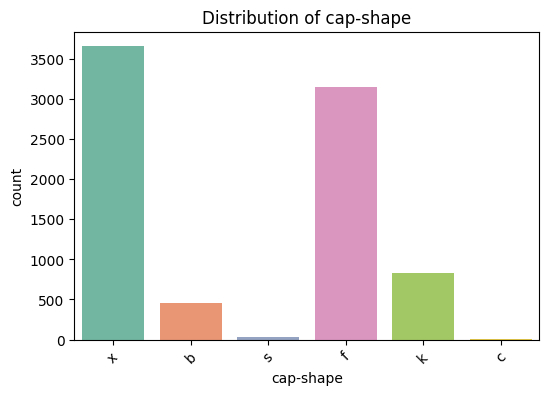

<ipython-input-21-7a006c733ffb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="Set2")


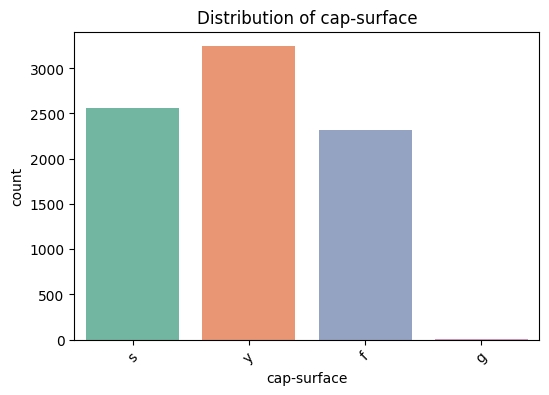

<ipython-input-21-7a006c733ffb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="Set2")


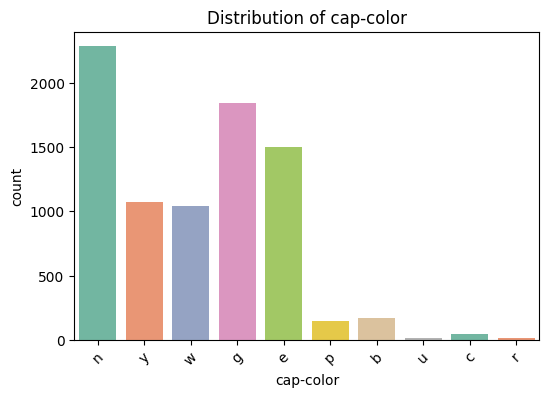

<ipython-input-21-7a006c733ffb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="Set2")


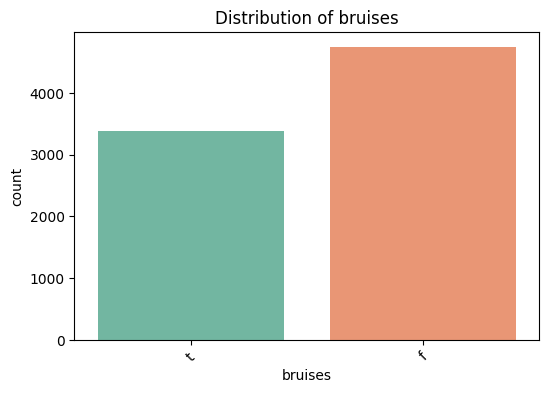

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Display dataset information
print(data.info())
print(data.describe())

# Check for missing values
print(data.isnull().sum())

# Countplot of target variable (edible vs poisonous)
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=data, palette='coolwarm')
plt.title("Distribution of Edible vs. Poisonous Mushrooms")
plt.show()

# Visualizing categorical features
for col in data.columns[1:5]:  # First few columns for visualization
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=data, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Convert categorical columns to numeric using Label Encoding
label_encoder = LabelEncoder()
for col in data.columns:
    data[col] = label_encoder.fit_transform(data[col])

# Split dataset into features (X) and target variable (y)
X = data.drop("class", axis=1)
y = data["class"]

# Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Define models
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVC": SVC(kernel='linear'),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

# Train & Evaluate Models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))
    results[name] = classification_report(y_test, y_pred, output_dict=True)  # Store results



Gaussian Naive Bayes Performance:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       843
           1       0.91      0.93      0.92       782

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625


Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


Decision Tree Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00    

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:37:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


                      precision    recall  f1-score  support
Gaussian Naive Bayes   0.922092  0.921846  0.921868   1625.0
Random Forest          1.000000  1.000000  1.000000   1625.0
Decision Tree          1.000000  1.000000  1.000000   1625.0
Logistic Regression    0.947706  0.947692  0.947696   1625.0
SVC                    0.973087  0.972923  0.972910   1625.0
K-Nearest Neighbors    0.996336  0.996308  0.996308   1625.0
XGBoost                1.000000  1.000000  1.000000   1625.0


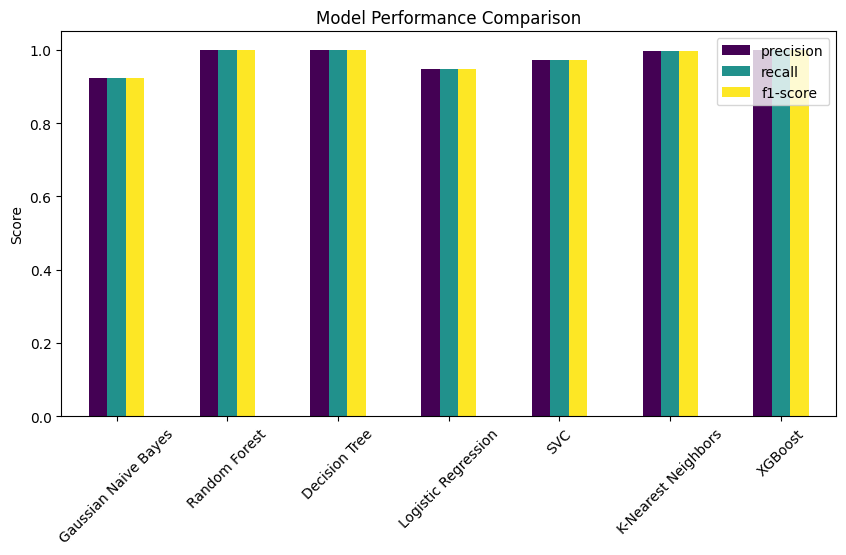

In [ ]:
import pandas as pd

# Convert results dictionary into a DataFrame for comparison
results_df = pd.DataFrame({model: results[model]['weighted avg'] for model in results}).T
results_df = results_df[['precision', 'recall', 'f1-score', 'support']]
print(results_df)

results_df.drop(columns=['support']).plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.legend(loc='best')
plt.show()


In [ ]:
# Sort by F1-score and get top 3
top_3 = results_df.sort_values(by=['f1-score'], ascending=False).head(3)

# Calculate a combined score (e.g., average of normalized metrics)
results_df['combined_score'] = (results_df['precision'] + results_df['recall'] + results_df['f1-score']) / 3

# Sort by the combined score and get top 3
top_3 = results_df.sort_values(by=['combined_score'], ascending=False).head(3)

# Print the best 3 algorithms
print("\nTop 3 Algorithms based on Combined Score:")
for index in top_3.index:
    print(f"- {index}: Combined Score = {top_3.loc[index, 'combined_score']:.4f}")


Top 3 Algorithms based on Combined Score:
- Random Forest: Combined Score = 1.0000
- Decision Tree: Combined Score = 1.0000
- XGBoost: Combined Score = 1.0000
